In [15]:
# EXPERIMENT 6 - AIML LAB
# Missing Value & Outlier Handling (Data Preprocessing)
# Step 1: Import Libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
# Step 2: Load Dataset
df = sns.load_dataset('titanic')
print("----- Original Missing Values -----")
print(df.isnull().sum())

----- Original Missing Values -----
survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64


In [16]:
# PART 1: HANDLING MISSING VALUES
# Fill numerical missing values with mean
for col in df.select_dtypes(include=np.number).columns:
    df[col] = df[col].fillna(df[col].mean())
# Fill categorical missing values with mode
for col in df.select_dtypes(include=['object', 'string']).columns:
    if col != 'deck':
        df[col] = df[col].fillna(df[col].mode()[0])
# FIX for categorical 'deck'
if "Unknown" not in df['deck'].cat.categories:
    df['deck'] = df['deck'].cat.add_categories("Unknown")
df['deck'] = df['deck'].fillna("Unknown")
print("\n----- Missing Values After Handling -----")
print(df.isnull().sum())


----- Missing Values After Handling -----
survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
deck           0
embark_town    0
alive          0
alone          0
dtype: int64


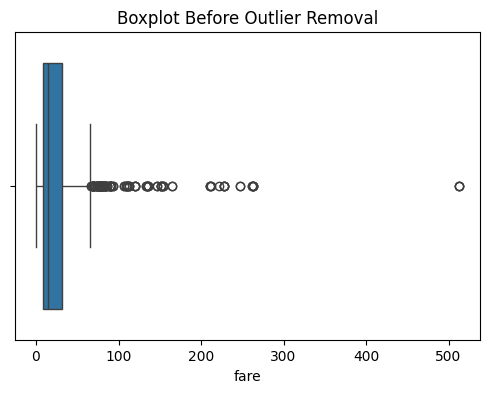


Lower Bound: -26.724
Upper Bound: 65.6344


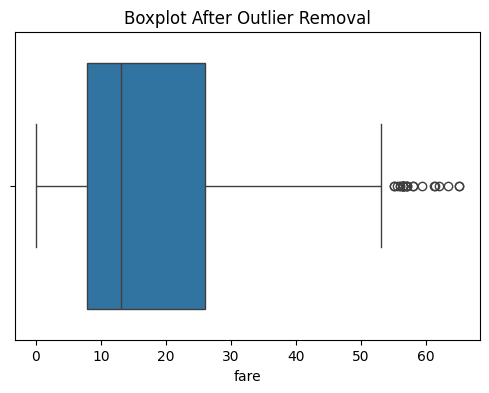

In [20]:
# PART 2: OUTLIER DETECTION & HANDLING
# Detect outliers using boxplot
plt.figure(figsize=(6,4))
sns.boxplot(x=df['fare'])
plt.title("Boxplot Before Outlier Removal")
plt.show()

# Using IQR Method
Q1 = df['fare'].quantile(0.25)
Q3 = df['fare'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
print("\nLower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

# Remove outliers
df_clean = df[(df['fare'] >= lower_bound) & (df['fare'] <= upper_bound)]
# Boxplot after removal
plt.figure(figsize=(6,4))
sns.boxplot(x=df_clean['fare'])
plt.title("Boxplot After Outlier Removal")
plt.show()

In [21]:
# FINAL DATASET INFO
print("\n----- Final Dataset Shape -----")
print("Before:", df.shape)
print("After:", df_clean.shape)

print("\nData Preprocessing Completed Successfully")


----- Final Dataset Shape -----
Before: (891, 15)
After: (775, 15)

Data Preprocessing Completed Successfully
